In [50]:
import os
import pathlib

import numpy as np
import matplotlib.pyplot as plt


In [94]:
path1 = pathlib.Path(
    "/Users/erik/.cellsepi/module_cache/ImageSegmentation_ImageSegmentation_0/Image:0_CSP-channel-pref_1_seg.npy")

path2 = pathlib.Path("/Users/erik/.cellsepi/module_cache/Review_Review_1/Image:0_CSP-channel-pref_1_seg.npy")

In [95]:
mask_1 = np.load(path1, allow_pickle=True).item()

In [96]:
mask_2 = np.load(path2, allow_pickle=True).item()

In [97]:
diff = (mask_1["masks"] > 0) * 1.0 - (mask_2["masks"] > 0) * 1.0
np.sum(diff)

np.float64(38640.0)

In [98]:
mask_1_mask = mask_1["masks"]
mask_2_mask = mask_2["masks"]
mask_ids = np.unique(mask_1_mask)[1:]

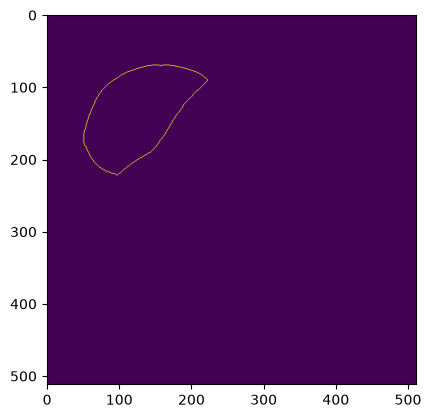

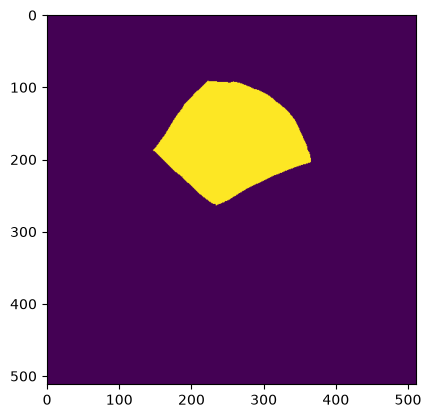

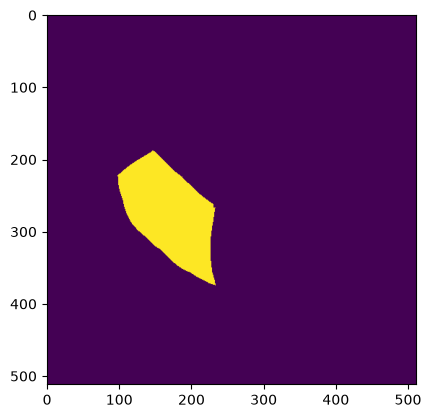

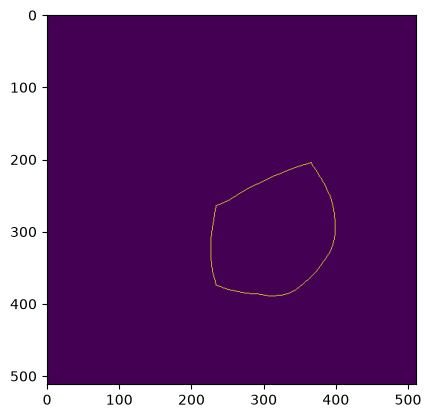

In [99]:
for m_id in mask_ids:
    m1 = mask_1_mask == m_id
    m2 = mask_2_mask == m_id
    plt.imshow(m1 * 1 - m2 * 1)
    plt.show()

# Flows Analysis

0
1
2
4


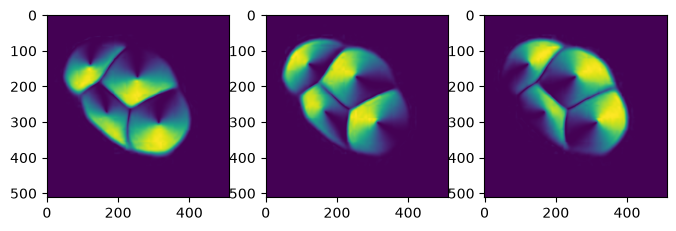

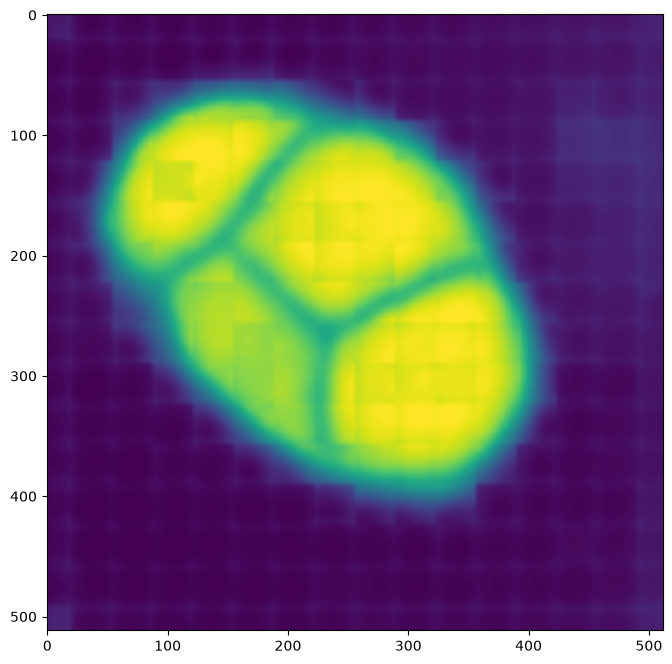

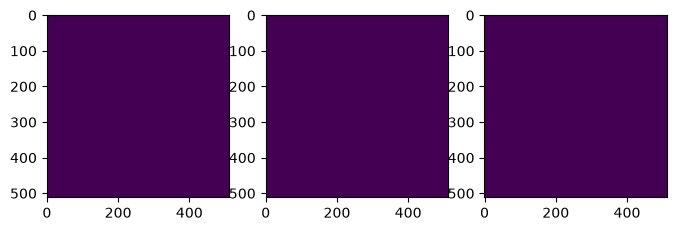

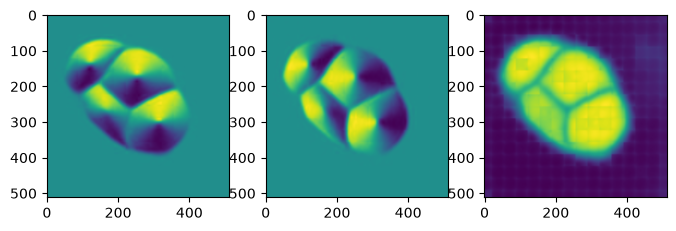

In [72]:

for iE, elem in enumerate(mask_1["flows"]):
    if not isinstance(elem, np.ndarray):
        continue

    print(iE)
    shape = elem.shape

    if elem.ndim == 3:

        fig, axes = plt.subplots(ncols=shape[0], nrows=1, figsize=np.array((8, 8)))
        if shape[0] == 1:
            axes = [axes]
        for ax, sub_elem in zip(axes, elem):
            ax.imshow(sub_elem)

        # plt.tight_layout
        # plt.suptitle(iE)

    elif elem.ndim == 4:
        fig, axes = plt.subplots(ncols=shape[-1], nrows=shape[0], figsize=np.array((8, 8)))
        elem = elem.transpose(0, 3, 1, 2)
        if shape[0] == 1:
            axes = [axes]
        for sub_ax, sub_elem in zip(axes, elem):
            for ax, sub_sub_elem in zip(sub_ax, sub_elem):
                ax.imshow(sub_sub_elem)

        pass

In [74]:
np.max(mask_1["flows"][2])

np.uint8(0)

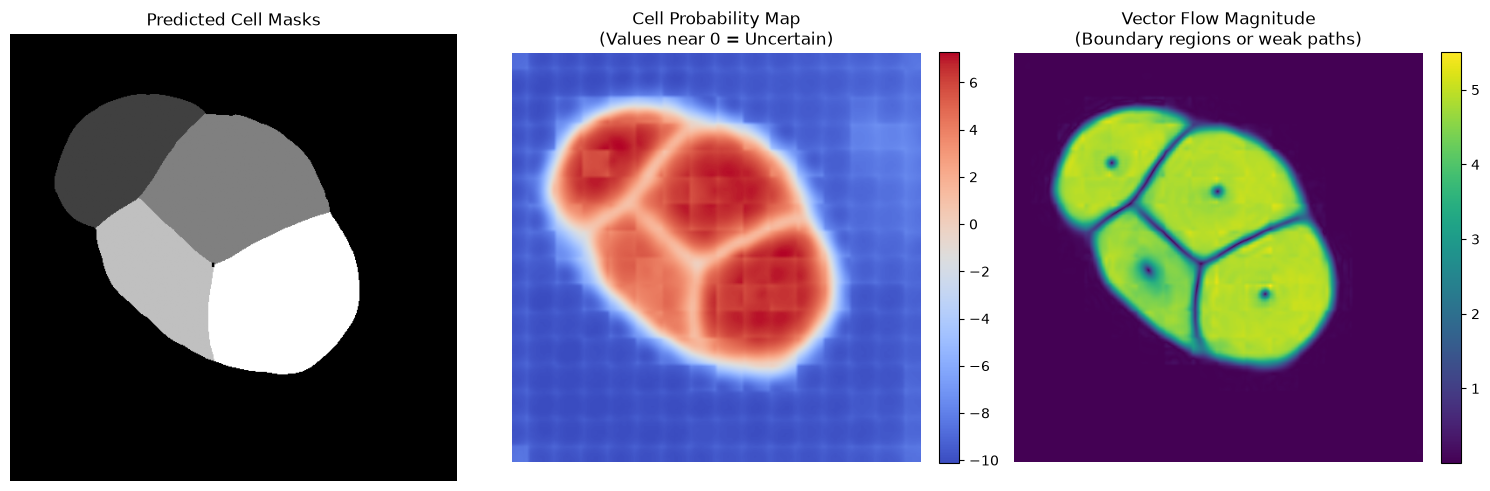

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load your Cellpose segmentation file
data = np.load(path1, allow_pickle=True).item()

masks = data['masks']
flows_list = data['flows']

# 2. Safely extract using the 5th element dimensions (3, 512, 512)
raw_outputs = flows_list[4]

dy = raw_outputs[0]         # Vertical vector field
dx = raw_outputs[1]         # Horizontal vector field
cell_prob = raw_outputs[2]  # Raw probability map (logits)

# 3. Calculate flow magnitude (Strength of the spatial vector paths)
flow_magnitude = np.sqrt(dy**2 + dx**2)

# 4. Plot the results side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot Mask boundaries for reference on the FIRST axis
axes[0].imshow(masks, cmap='gray')
axes[0].set_title('Predicted Cell Masks')
axes[0].axis('off')

# Plot Cell Probability on the SECOND axis
im1 = axes[1].imshow(cell_prob, cmap='coolwarm')
axes[1].set_title('Cell Probability Map\n(Values near 0 = Uncertain)')
axes[1].axis('off')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Plot Flow Magnitude on the THIRD axis
im2 = axes[2].imshow(flow_magnitude, cmap='viridis')
axes[2].set_title('Vector Flow Magnitude\n(Boundary regions or weak paths)')
axes[2].axis('off')
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


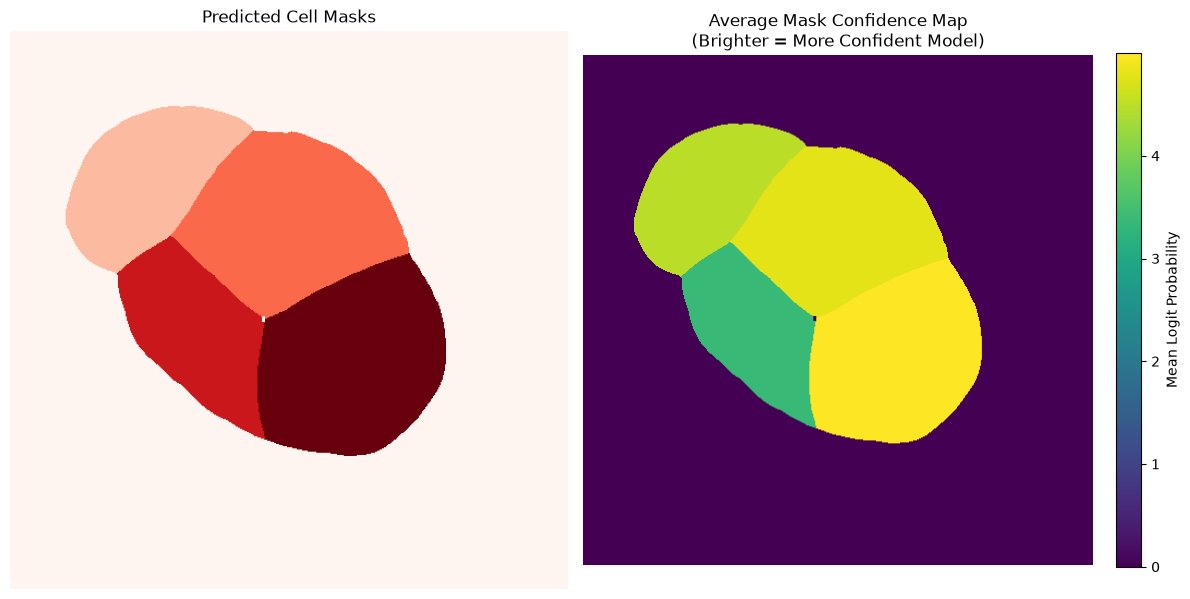

In [79]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load your Cellpose segmentation file
data = np.load(path1, allow_pickle=True).item()

masks = data['masks']
flows_list = data['flows']

# Extract raw cell probability map (logits) from the 5th element
cell_prob = flows_list[4][2]

# 2. Initialize a blank image for confidence mapping
# Using float64 so background can be filled with NaNs or 0s
confidence_map = np.zeros_like(masks, dtype=np.float64)

# Get all unique cell mask IDs (excluding 0, which is background)
unique_mask_ids = np.unique(masks)
unique_mask_ids = unique_mask_ids[unique_mask_ids != 0]

# 3. Calculate average confidence (probability) per mask
for mask_id in unique_mask_ids:
    # Create a boolean array for the current cell pixels
    cell_pixels = (masks == mask_id)

    # Calculate the mean probability score of these specific pixels
    mean_confidence = np.mean(cell_prob[cell_pixels])

    # Assign this single scalar score to all pixels of the mask
    confidence_map[cell_pixels] = mean_confidence

# 4. Plot the results side-by-side with your original masks
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot the standard discrete masks
axes[0].imshow(masks, cmap='Reds')
axes[0].set_title('Predicted Cell Masks')
axes[0].axis('off')

# Plot the continuous confidence scores per mask
# 'YlOrRd' or 'viridis' work well here. Pixels with 0 value remain background.
im = axes[1].imshow(confidence_map, cmap='viridis')
axes[1].set_title('Average Mask Confidence Map\n(Brighter = More Confident Model)')
axes[1].axis('off')

# Add a colorbar specifically for the confidence map
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label='Mean Logit Probability')

plt.tight_layout()
plt.show()
